In [1]:
########### Logistic regression ########################


import pandas as pd
import numpy as np
import statsmodels.formula.api as sm
import os
import statsmodels.api as sm
from matplotlib import pylab
import pylab as pl

In [2]:
# import dataset

os.chdir(r'C:\Users\HP\Desktop\Python for Data Science\Machine Learning\Logistic regression')
data = pd.read_csv(r"C:\Users\HP\Desktop\Python for Data Science\Machine Learning\Logistic regression\fitness_dataset.csv")
pd.set_option('display.max_columns', None) #show all columns
data.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


In [3]:
## Information Value ##
def iv_woe(data, target, bins=10, show_woe=False):
    
    #Empty Dataframe
    newDF,woeDF = pd.DataFrame(), pd.DataFrame()
    
    #Extract Column Names
    cols = data.column

In [4]:
import numpy as np
import pandas as pd


def iv_woe(data, target, bins=10, show_woe=False):
    # Initialize empty DataFrames to store the results
    newDF = pd.DataFrame()
    woeDF = pd.DataFrame()

    # DEFINE COLS: Get all column names from the dataset
    cols = data.columns

    # Run WOE and IV on all the independent variables
    for ivars in cols[~cols.isin([target])]:
        if (data[ivars].dtype.kind in "bifc") and (
            len(np.unique(data[ivars])) > 10
        ):
            binned_x = pd.qcut(data[ivars], bins, duplicates="drop")
            d0 = pd.DataFrame({"x": binned_x, "y": data[target]})
        else:
            d0 = pd.DataFrame({"x": data[ivars], "y": data[target]})

        d = d0.groupby("x", as_index=False).agg({"y": ["count", "sum"]})
        d.columns = ["Cutoff", "N", "Events"]
        d["% of Events"] = np.maximum(d["Events"], 0.5) / d["Events"].sum()
        d["Non-Events"] = d["N"] - d["Events"]
        d["% of Non-Events"] = (
            np.maximum(d["Non-Events"], 0.5) / d["Non-Events"].sum()
        )
        d["WoE"] = np.log(d["% of Events"] / d["% of Non-Events"])
        d["IV"] = d["WoE"] * (d["% of Events"] - d["% of Non-Events"])
        d.insert(loc=0, column="Variable", value=ivars)

        print(
            "Information value of "
            + ivars
            + " is "
            + str(round(d["IV"].sum(), 6))
        )

        temp = pd.DataFrame(
            {"Variable": [ivars], "IV": [d["IV"].sum()]},
            columns=["Variable", "IV"],
        )
        newDF = pd.concat([newDF, temp], axis=0)
        woeDF = pd.concat([woeDF, d], axis=0)

        # Show WOE Table if requested
        if show_woe == True:
            print(d)

    # Return the dataframes after processing all variables
    return newDF, woeDF


# --- Calling the function ---
# (Ensure your 'data' DataFrame is already loaded before running this)
iv, woe = iv_woe(data=data, target="is_fit", bins=10, show_woe=True)
print(iv)
print(woe)

Information value of age is 0.19642
  Variable          Cutoff    N  Events  % of Events  Non-Events  \
0      age  (17.999, 24.0]  217     123     0.153942          94   
1      age    (24.0, 31.0]  211     110     0.137672         101   
2      age    (31.0, 38.0]  199      95     0.118899         104   
3      age    (38.0, 43.0]  190      87     0.108886         103   
4      age    (43.0, 49.0]  186      77     0.096370         109   
5      age    (49.0, 55.0]  215      77     0.096370         138   
6      age    (55.0, 62.0]  210      69     0.086358         141   
7      age    (62.0, 68.0]  198      67     0.083855         131   
8      age    (68.0, 74.0]  193      54     0.067584         139   
9      age    (74.0, 79.0]  181      40     0.050063         141   

   % of Non-Events       WoE        IV  
0         0.078268  0.676438  0.051189  
1         0.084097  0.492909  0.026408  
2         0.086595  0.317035  0.010242  
3         0.085762  0.238728  0.005520  
4         

C:\Users\HP\AppData\Local\Temp\ipykernel_36520\4063448350.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d = d0.groupby("x", as_index=False).agg({"y": ["count", "sum"]})
C:\Users\HP\AppData\Local\Temp\ipykernel_36520\4063448350.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d = d0.groupby("x", as_index=False).agg({"y": ["count", "sum"]})
C:\Users\HP\AppData\Local\Temp\ipykernel_36520\4063448350.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

In [5]:
iv = pd.DataFrame(iv)
iv.sort_values(["IV"],ascending=[0])

## IV ends here ########

,Variable,IV
0,activity_index,0.568903
0,smokes,0.402670
0,nutrition_quality,0.307247
0,age,0.196420
0,gender,0.086954
0,weight_kg,0.078719
0,sleep_hours,0.076491
0,height_cm,0.026973
0,heart_rate,0.026851
0,blood_pressure,0.015569


In [6]:
def outlier (data,age):
 Q1 = data[age].quantile(0.25)
 Q3 = data[age].quantile(0.75)
 IQR = Q3 - Q1
 data= data.loc[~((data[age] < (Q1 - 1.5 * IQR)) | (data[age] > (Q3 + 1.5 * IQR))),]
 return data

In [9]:
data.boxplot(column=["age"]) #no outlier

<Axes: >

In [10]:
data.boxplot(column=["age"])
data = outlier(data,"age")

In [11]:
data.boxplot(column=["height_cm"])
data = outlier(data,"height_cm")

In [12]:
data.boxplot(column=["weight_kg"])
data = outlier(data,"weight_kg")

In [13]:
data.boxplot(column=["heart_rate"])
data = outlier(data,"heart_rate")

In [14]:
data.boxplot(column=["blood_pressure"])
data = outlier(data,"blood_pressure")

In [15]:
data.boxplot(column=["sleep_hours"])
data = outlier(data,"sleep_hours")

In [16]:
data.boxplot(column=["nutrition_quality"])
data = outlier(data,"nutrition_quality")

In [17]:
data.boxplot(column=["activity_index"])
data = outlier(data,"activity_index")

In [18]:
#missing value treatment

data.isnull().sum() #show is any variable has any missing value

age                    0
height_cm              0
weight_kg              0
heart_rate             0
blood_pressure         0
sleep_hours          157
nutrition_quality      0
activity_index         0
smokes                 0
gender                 0
is_fit                 0
dtype: int64

In [19]:
data=data.dropna()

In [20]:
data.isnull().sum()

age                  0
height_cm            0
weight_kg            0
heart_rate           0
blood_pressure       0
sleep_hours          0
nutrition_quality    0
activity_index       0
smokes               0
gender               0
is_fit               0
dtype: int64

In [21]:
data.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1
5,25,172,85,81.2,119.2,7.7,7.35,4.08,yes,M,0
6,78,193,83,79.6,132.5,7.4,2.16,3.42,yes,F,0


In [30]:
data["smokes"] = (data["smokes"].astype(str).str.strip().str.lower()
                  .map({"no": 0, "0": 0, "yes": 1, "1": 1}))

In [31]:
data.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,1,F,1
5,25,172,85,81.2,119.2,7.7,7.35,4.08,1,M,0
6,78,193,83,79.6,132.5,7.4,2.16,3.42,1,F,0


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1806 entries, 1 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1806 non-null   int64  
 1   height_cm          1806 non-null   int64  
 2   weight_kg          1806 non-null   int64  
 3   heart_rate         1806 non-null   float64
 4   blood_pressure     1806 non-null   float64
 5   sleep_hours        1806 non-null   float64
 6   nutrition_quality  1806 non-null   float64
 7   activity_index     1806 non-null   float64
 8   smokes             1806 non-null   int64  
 9   gender             1806 non-null   object 
 10  is_fit             1806 non-null   int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 233.9+ KB


In [33]:
data.describe()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,is_fit
count,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000
mean,49.171650,174.524917,82.373200,70.043688,119.860631,7.507364,5.027182,2.996678,0.445736,0.398671
std,17.931739,14.387560,21.815145,11.519850,14.425638,1.498700,2.862611,1.134082,0.497184,0.489760
min,18.000000,150.000000,30.000000,45.000000,90.000000,4.000000,0.000000,1.000000,0.000000,0.000000
25%,34.000000,162.000000,64.000000,62.100000,109.825000,6.500000,2.540000,2.032500,0.000000,0.000000
50%,50.000000,174.000000,83.000000,70.100000,119.900000,7.500000,5.060000,2.990000,0.000000,0.000000
75%,65.000000,187.000000,102.000000,78.200000,129.800000,8.600000,7.460000,3.917500,1.000000,1.000000
max,79.000000,199.000000,119.000000,102.300000,159.100000,11.700000,10.000000,4.990000,1.000000,1.000000


In [34]:
data = pd.get_dummies(
    data,
    columns=[
        'gender'
    ],
    drop_first=True,
    dtype=int
)


data.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,is_fit,gender_M
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,1,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,1,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,1,1,0
5,25,172,85,81.2,119.2,7.7,7.35,4.08,1,0,1
6,78,193,83,79.6,132.5,7.4,2.16,3.42,1,0,0


In [35]:
train_cols = data.loc[:,[
    "age",
    "height_cm",
    "weight_kg",
    "heart_rate",
    "blood_pressure",
    "sleep_hours",
    "nutrition_quality",
    "activity_index",
    "smokes",
    "gender_M"
]]

train_cols.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender_M
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,1,0
5,25,172,85,81.2,119.2,7.7,7.35,4.08,1,1
6,78,193,83,79.6,132.5,7.4,2.16,3.42,1,0


In [36]:
# model
logit = sm.Logit(data['is_fit'], train_cols)
# fit the model
result = logit.fit()
result.summary()#all p values are significant

Optimization terminated successfully.
         Current function value: 0.452056
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 is_fit   No. Observations:                 1806
Model:                          Logit   Df Residuals:                     1796
Method:                           MLE   Df Model:                            9
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:                  0.3278
Time:                        23:04:32   Log-Likelihood:                -816.41
converged:                       True   LL-Null:                       -1214.5
Covariance Type:            nonrobust   LLR p-value:                1.445e-165
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
age                  -0.0435      0.004    -11.885      0.000      -0.051      -0.036
height_cm             0.0009      0.003      0.307      0.759      -0.005       0.007
weight_kg            -0.0081      0.003     -2.919      0.004      -0.014      -0.003
heart_rate           -0.0035      0.005     -0.699      0.484      -0.013       0.006
blood_pressure       -0.0247      0.004     -6.510      0.000      -0.032      -0.017
sleep_hours           0.1932      0.040      4.858      0.000       0.115       0.271
nutrition_quality     0.2780      0.023     11.886      0.000       0.232       0.324
activity_index        0.9332      0.062     15.091      0.000       0.812       1.054
smokes               -1.9174      0.137    -14.042      0.000      -2.185      -1.650
gender_M              0.8551      0.125      6.868      0.000       0.611       1.099
=====================================================================================
"""

In [37]:
var = pd.DataFrame(round(result.pvalues,3)) # shows p value
var["coeff"] = result.params #coefficients
# rename columns
var.columns.values[[0,1]]= ["p value","coefficients"]
var

,p value,coefficients
age,0.000,-0.043511
height_cm,0.759,0.000947
weight_kg,0.004,-0.008077
heart_rate,0.484,-0.003493
blood_pressure,0.000,-0.024711
sleep_hours,0.000,0.193245
nutrition_quality,0.000,0.277960
activity_index,0.000,0.933152
smokes,0.000,-1.917415
gender_M,0.000,0.855150


In [38]:
cov = result.cov_params()
std_err = np.sqrt(np.diag(cov))
var["z"]=result.params.values/std_err
var

,p value,coefficients,z
age,0.000,-0.043511,-11.884805
height_cm,0.759,0.000947,0.306550
weight_kg,0.004,-0.008077,-2.918540
heart_rate,0.484,-0.003493,-0.699492
blood_pressure,0.000,-0.024711,-6.509911
sleep_hours,0.000,0.193245,4.857944
nutrition_quality,0.000,0.277960,11.885768
activity_index,0.000,0.933152,15.091455
smokes,0.000,-1.917415,-14.041969
gender_M,0.000,0.855150,6.868455


In [39]:
result.conf_int() # confidence interval

,0,1
age,-0.050687,-0.036336
height_cm,-0.005107,0.007001
weight_kg,-0.013500,-0.002653
heart_rate,-0.013280,0.006294
blood_pressure,-0.032150,-0.017271
sleep_hours,0.115279,0.271211
nutrition_quality,0.232124,0.323795
activity_index,0.811962,1.054343
smokes,-2.185046,-1.649784
gender_M,0.611127,1.099173


In [40]:
np.exp(result.params) #odds ratio (may igmore it for the time being)

age                  0.957422
height_cm            1.000947
weight_kg            0.991956
heart_rate           0.996513
blood_pressure       0.975592
sleep_hours          1.213180
nutrition_quality    1.320433
activity_index       2.542511
smokes               0.146986
gender_M             2.351727
dtype: float64

In [41]:
### VIF Calculation

import pandas as pd
import numpy as np
import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [42]:
result = sm.ols(
    formula="""is_fit~age+height_cm+weight_kg+
    heart_rate+blood_pressure+sleep_hours+nutrition_quality+activity_index+
    smokes+gender_M""",
    data=data
).fit()

In [43]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 is_fit   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     102.5
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          4.35e-168
Time:                        23:07:38   Log-Likelihood:                -865.07
No. Observations:                1806   AIC:                             1752.
Df Residuals:                    1795   BIC:                             1813.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.1678      0.166     -1.012      0.312      -0.493       0.157
age                  -0.0063      0.001    -12.285      0.000      -0.007      -0.005
height_cm             0.0019      0.001      2.960      0.003       0.001       0.003
weight_kg            -0.0009      0.000     -2.153      0.031      -0.002   -8.11e-05
heart_rate            0.0008      0.001      0.992      0.321      -0.001       0.002
blood_pressure       -0.0023      0.001     -3.643      0.000      -0.004      -0.001
sleep_hours           0.0346      0.006      5.612      0.000       0.023       0.047
nutrition_quality     0.0423      0.003     13.101      0.000       0.036       0.049
activity_index        0.1460      0.008     17.883      0.000       0.130       0.162
smokes               -0.2885      0.019    -15.516      0.000      -0.325      -0.252
gender_M              0.1328      0.018      7.181      0.000       0.097       0.169
==============================================================================
Omnibus:                       86.792   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.326
Skew:                           0.241   Prob(JB):                     3.21e-11
Kurtosis:                       2.360   Cond. No.                     4.38e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.38e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [44]:
#remove variable based on vif
#all vif values are under 2, hence no variable is removed

var = pd.DataFrame(round(result.pvalues,3))# shows p value
var["coeff"] = result.params#coefficients
variables = result.model.exog #.if I had saved data as rock

In [45]:
# this it would have looked like rock.model.exog
vif = [variance_inflation_factor(variables, i) for i in range(variables.shape[1])]
vif 

[np.float64(323.23201029438036),
 np.float64(1.0044409323188328),
 np.float64(1.0070783032590034),
 np.float64(1.0055532137067174),
 np.float64(1.002969888373776),
 np.float64(1.006380126500483),
 np.float64(1.005340219296366),
 np.float64(1.00301914286609),
 np.float64(1.0073963884495662),
 np.float64(1.0048729529380764),
 np.float64(1.0042230945070842)]

In [46]:
var["vif"] = vif
var ## final variables after vif

,0,coeff,vif
Intercept,0.312,-0.167775,323.232010
age,0.000,-0.006333,1.004441
height_cm,0.003,0.001904,1.007078
weight_kg,0.031,-0.000913,1.005553
heart_rate,0.321,0.000795,1.002970
blood_pressure,0.000,-0.002336,1.006380
sleep_hours,0.000,0.034630,1.005340
nutrition_quality,0.000,0.042275,1.003019
activity_index,0.000,0.145973,1.007396
smokes,0.000,-0.288530,1.004873


In [47]:
train_cols = data.loc[:,[
    "age",
    "height_cm",
    "weight_kg",
    "heart_rate",
    "blood_pressure",
    "sleep_hours",
    "nutrition_quality",
    "activity_index",
    "smokes",
    "gender_M"
]]

In [48]:
inputData=train_cols  # ind var
outputData=data.loc[:,"is_fit"]  # dep var

In [49]:
outputData.count()

np.int64(1806)

In [51]:
from sklearn.linear_model import LogisticRegression
logit1=LogisticRegression()
logit1.fit(inputData,outputData)
logit1.score(inputData,outputData)

y_pred = logit1.predict(train_cols)
prob = logit1.predict_proba(train_cols)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
#transform the probabilities into DataFrame
# it shows probability for both

prob = pd.DataFrame(prob)
prob = prob.iloc[:,1] #showing the probability of being 1
prob = prob.reset_index()
prob.head()

,index,1
0,0,0.558176
1,1,0.881563
2,2,0.648153
3,3,0.803604
4,4,0.016929


In [53]:
outputData = pd.DataFrame(outputData)
outputData.head()
outputData = outputData.reset_index()
outputData = outputData.iloc[:,1]
outputData.head()

0    1
1    1
2    1
3    0
4    0
Name: is_fit, dtype: int64

In [54]:
rock = pd.concat([outputData,prob], axis=1)
rock = rock.iloc[:,[0,2]] #this line might give error, check the column index
rock.head()
df = rock.copy()
df.columns = ["y","p"]
df.head()

,y,p
0,1,0.558176
1,1,0.881563
2,1,0.648153
3,0,0.803604
4,0,0.016929


In [55]:
###Confusion matrix with sklearn

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
confusion_matrix(logit1.predict(inputData),outputData) # this is experimental not required

array([[919, 213],
       [167, 507]])

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(logit1.predict(inputData),outputData))
print(classification_report(logit1.predict(inputData),outputData))

[[919 213]
 [167 507]]
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1132
           1       0.70      0.75      0.73       674

    accuracy                           0.79      1806
   macro avg       0.78      0.78      0.78      1806
weighted avg       0.79      0.79      0.79      1806



In [57]:
## Computing false and true positive rates

fpr, tpr,_=roc_curve(logit1.predict(inputData),outputData,drop_intermediate=False)

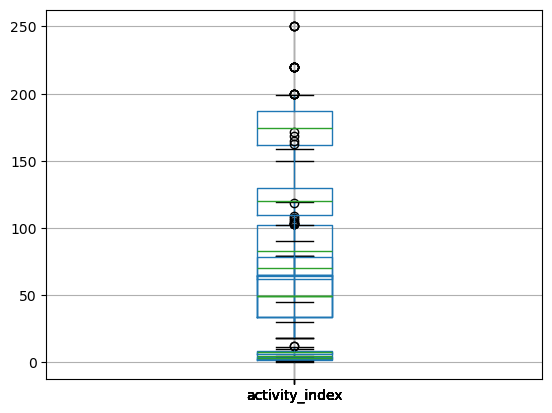

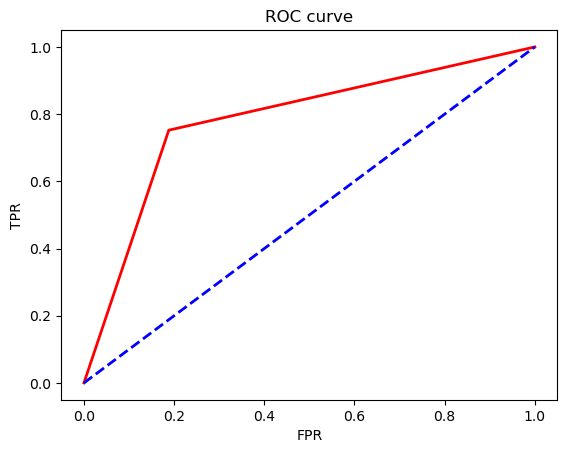

np.float64(0.7820314875591112)

In [58]:
import matplotlib.pyplot as plt
plt.figure()
##Adding the ROC
plt.plot(fpr, tpr, color='red',
 lw=2, label='ROC curve')
##Random FPR and TPR
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
##Title and label
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve')
plt.show()
roc_auc_score(logit1.predict(inputData),outputData)

In [59]:
## ks stat

df = rock.copy()
df.columns = ["y","p"]
df.head()

,y,p
0,1,0.558176
1,1,0.881563
2,1,0.648153
3,0,0.803604
4,0,0.016929


In [60]:
def ks(data=None,target=None, prob=None):
    data['target0'] = 1 - data[target]
    data['bucket'] = pd.qcut(data[prob], 10)
    grouped = data.groupby('bucket', as_index = False)
    kstable = pd.DataFrame()
    kstable['min_prob'] = grouped.min()[prob]
    kstable['max_prob'] = grouped.max()[prob]
    kstable['events']   = grouped.sum()[target]
    kstable['nonevents'] = grouped.sum()['target0']
    kstable = kstable.sort_values(by="min_prob", ascending=False).reset_index(drop = True)
    kstable['event_rate'] = (kstable.events / data[target].sum()).apply('{0:.2%}'.format)
    kstable['nonevent_rate'] = (kstable.nonevents / data['target0'].sum()).apply('{0:.2%}'.format)
    kstable['cum_eventrate']=(kstable.events / data[target].sum()).cumsum()
    kstable['cum_noneventrate']=(kstable.nonevents / data['target0'].sum()).cumsum()
    kstable['KS'] = np.round(kstable['cum_eventrate']-kstable['cum_noneventrate'], 3) * 100

    #Formating
    kstable['cum_eventrate']= kstable['cum_eventrate'].apply('{0:.2%}'.format)
    kstable['cum_noneventrate']= kstable['cum_noneventrate'].apply('{0:.2%}'.format)
    kstable.index = range(1,11)
    kstable.index.rename('Decile', inplace=True)
    pd.set_option('display.max_columns', 9)
    print(kstable)
    
    #Display KS
    from colorama import Fore
    print(Fore.RED + "KS is " + str(max(kstable['KS']))+"%"+ " at decile " + str((kstable.index[kstable['KS']==max(kstable['KS'])][0])))
    return(kstable)

In [61]:
mydf = ks(data=df,target="y", prob="p")

        min_prob  max_prob  events  nonevents event_rate nonevent_rate  \
Decile                                                                   
1       0.871906  0.993387     168         13     23.33%         1.20%   
2       0.733149  0.871802     147         33     20.42%         3.04%   
3       0.578471  0.732139     115         66     15.97%         6.08%   
4       0.471994  0.577299     103         77     14.31%         7.09%   
5       0.338044  0.471224      76        105     10.56%         9.67%   
6       0.242023  0.337946      48        132      6.67%        12.15%   
7       0.160241  0.241595      18        163      2.50%        15.01%   
8       0.090623  0.159386      20        160      2.78%        14.73%   
9       0.042902  0.089874      14        167      1.94%        15.38%   
10      0.001090  0.042598      11        170      1.53%        15.65%   

       cum_eventrate cum_noneventrate    KS  
Decile                                       
1             23.33

C:\Users\HP\AppData\Local\Temp\ipykernel_36520\572846000.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby('bucket', as_index = False)


In [62]:
## merging data and probability score

df = rock.copy()
df.columns = ["y","p"]
df.reset_index(inplace=True)
df.head()

,index,y,p
0,0,1,0.558176
1,1,1,0.881563
2,2,1,0.648153
3,3,0,0.803604
4,4,0,0.016929


In [63]:
kane = data.copy()
kane.reset_index(inplace=True)
kane.head()

,index,age,height_cm,weight_kg,...,activity_index,smokes,is_fit,gender_M
0,1,69,186,95,...,3.19,0,1,0
1,3,32,189,83,...,3.68,0,1,1
2,4,60,175,99,...,4.83,1,1,0
3,5,25,172,85,...,4.08,1,0,1
4,6,78,193,83,...,3.42,1,0,0


In [64]:
final = pd.concat([df,kane],axis=1)
final.head()

,index,y,p,index,...,activity_index,smokes,is_fit,gender_M
0,0,1,0.558176,1,...,3.19,0,1,0
1,1,1,0.881563,3,...,3.68,0,1,1
2,2,1,0.648153,4,...,4.83,1,1,0
3,3,0,0.803604,5,...,4.08,1,0,1
4,4,0,0.016929,6,...,3.42,1,0,0


In [65]:
final.to_csv('fitness_predicted.csv',index=False) # export data to local drive